# 02 — Decoder-Only Transformer LM & Architecture Ablation (Task 2)

Trains the from-scratch MiniGPT as an autoregressive Hindi language model, reports
validation perplexity, generates text, and runs a controlled ablation: **vanilla**
(learned position embeddings + LayerNorm + ReLU-MLP) vs **modern** (RoPE + RMSNorm +
SwiGLU), same parameter budget and step count, trained by `scripts/train_lm.py` in
the background (see `outputs/logs/lm_vanilla_metrics.csv` / `lm_modern_metrics.csv`).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.config import CKPT_DIR, LOGS_DIR, ModelConfig, SEED, SPLITS_DIR, get_device, set_seed
from src.data import LMDataset
from src.model import GPTLanguageModel, MiniGPT, count_parameters
from src.generate import generate
from src.tokenizer import load_tokenizer
from src.train import evaluate_lm
from src import plots

set_seed(SEED)
plots.setup_style()
device = get_device()
sp = load_tokenizer()
print('Device:', device, '| Vocab:', sp.vocab_size())

Device: cuda | Vocab: 5000


## 2.1 Training curves: vanilla vs modern

In [2]:
vanilla_log = pd.read_csv(LOGS_DIR / 'lm_vanilla_metrics.csv')
modern_log = pd.read_csv(LOGS_DIR / 'lm_modern_metrics.csv')
print('Vanilla final:', vanilla_log.iloc[-1][['step', 'train_loss', 'val_loss', 'val_ppl']].to_dict())
print('Modern final :', modern_log.iloc[-1][['step', 'train_loss', 'val_loss', 'val_ppl']].to_dict())
print('\nBest (lowest) val perplexity:')
print('  Vanilla:', vanilla_log['val_ppl'].min())
print('  Modern :', modern_log['val_ppl'].min())

Vanilla final: {'step': 15000.0, 'train_loss': 3.9044, 'val_loss': 3.3616, 'val_ppl': 28.834}
Modern final : {'step': 15000.0, 'train_loss': 3.7068, 'val_loss': 3.3174, 'val_ppl': 27.588}

Best (lowest) val perplexity:
  Vanilla: 28.834
  Modern : 27.588


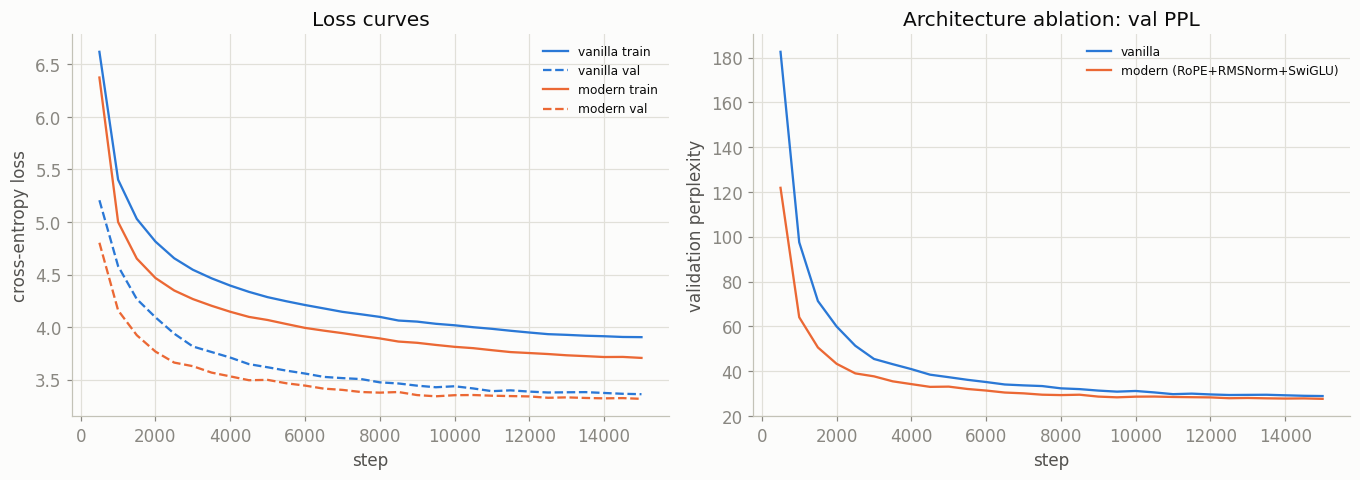

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(vanilla_log['step'], vanilla_log['train_loss'], color=plots.CATEGORICAL[0], label='vanilla train')
axes[0].plot(vanilla_log['step'], vanilla_log['val_loss'], color=plots.CATEGORICAL[0], linestyle='--', label='vanilla val')
axes[0].plot(modern_log['step'], modern_log['train_loss'], color=plots.CATEGORICAL[5], label='modern train')
axes[0].plot(modern_log['step'], modern_log['val_loss'], color=plots.CATEGORICAL[5], linestyle='--', label='modern val')
axes[0].set_xlabel('step'); axes[0].set_ylabel('cross-entropy loss'); axes[0].set_title('Loss curves')
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(vanilla_log['step'], vanilla_log['val_ppl'], color=plots.CATEGORICAL[0], label='vanilla')
axes[1].plot(modern_log['step'], modern_log['val_ppl'], color=plots.CATEGORICAL[5], label='modern (RoPE+RMSNorm+SwiGLU)')
axes[1].set_xlabel('step'); axes[1].set_ylabel('validation perplexity'); axes[1].set_title('Architecture ablation: val PPL')
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plots.savefig(fig, '02_lm_ablation_curves')
plt.show()

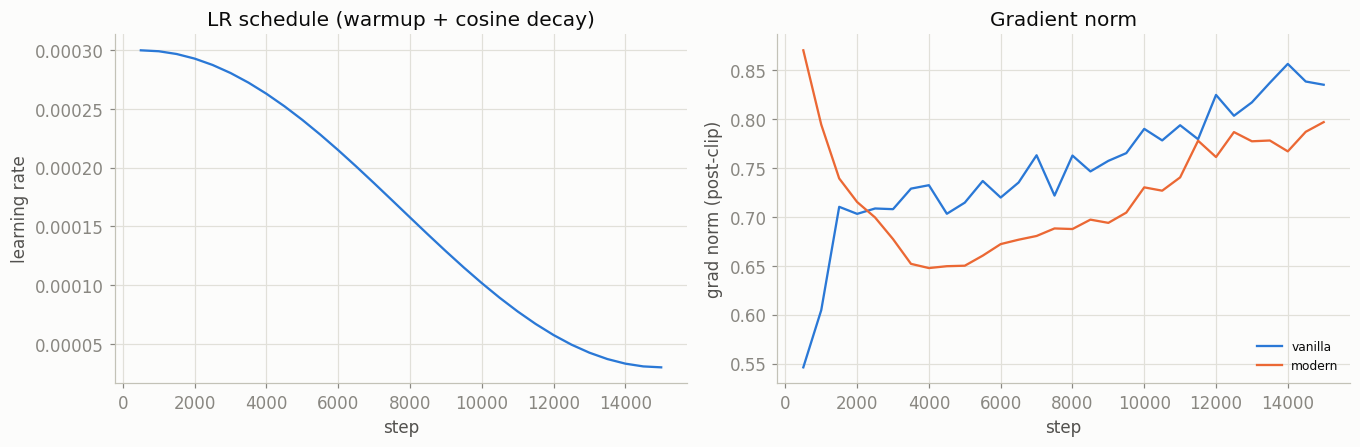

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(vanilla_log['step'], vanilla_log['lr'], color=plots.CATEGORICAL[0])
axes[0].set_xlabel('step'); axes[0].set_ylabel('learning rate'); axes[0].set_title('LR schedule (warmup + cosine decay)')

axes[1].plot(vanilla_log['step'], vanilla_log['grad_norm'], color=plots.CATEGORICAL[0], label='vanilla')
axes[1].plot(modern_log['step'], modern_log['grad_norm'], color=plots.CATEGORICAL[5], label='modern')
axes[1].set_xlabel('step'); axes[1].set_ylabel('grad norm (post-clip)'); axes[1].set_title('Gradient norm')
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plots.savefig(fig, '02_lm_schedule_gradnorm')
plt.show()

## 2.2 Load the best checkpoint of each architecture

In [5]:
def load_lm(run_name, arch, n_layer=8, n_head=8, n_embd=512, block_size=256):
    cfg = ModelConfig(vocab_size=sp.vocab_size(), block_size=block_size, n_layer=n_layer,
                       n_head=n_head, n_embd=n_embd, dropout=0.0, arch=arch, pad_id=sp.pad_id())
    backbone = MiniGPT(cfg).to(device)
    model = GPTLanguageModel(backbone, vocab_size=cfg.vocab_size).to(device)
    ckpt = torch.load(CKPT_DIR / f'{run_name}_best.pt', map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f'{run_name}: step={ckpt["step"]}, best_val_ppl={ckpt["best_val_ppl"]:.3f}, params={count_parameters(model):,}')
    return model, cfg

vanilla_model, vanilla_cfg = load_lm('lm_vanilla', 'vanilla')
modern_model, modern_cfg = load_lm('lm_modern', 'modern')

lm_vanilla: step=15000, best_val_ppl=28.834, params=27,894,784


lm_modern: step=15000, best_val_ppl=27.588, params=27,767,296


## 2.3 Final validation perplexity & bits-per-character (full val set)

In [6]:
from torch.utils.data import DataLoader

val_ds = LMDataset([], sp, block_size=256, eos_id=sp.eos_id(), cache_path=SPLITS_DIR / 'lm_val_tokens.pt')
val_loader = DataLoader(val_ds, batch_size=64, shuffle=True, num_workers=0, drop_last=True)

import math
for name, model in [('vanilla', vanilla_model), ('modern', modern_model)]:
    val_loss, val_ppl = evaluate_lm(model, val_loader, device, max_iters=200, amp=True)
    bpc = val_loss / math.log(2)  # nats -> bits; approximates bits-per-token here (subword, not char)
    print(f'{name:8s} | val_loss={val_loss:.4f} | val_ppl={val_ppl:.3f} | bits/token={bpc:.3f}')

vanilla  | val_loss=3.3629 | val_ppl=28.874 | bits/token=4.852


modern   | val_loss=3.3199 | val_ppl=27.658 | bits/token=4.790


## 2.4 Autoregressive Hindi text generation (50 tokens)

In [7]:
prompts = [
    'भारत एक विशाल देश है',
    'विज्ञान और तकनीक के क्षेत्र में',
    'महात्मा गांधी ने कहा था कि',
]

gen_lines = []
for name, model in [('vanilla', vanilla_model), ('modern', modern_model)]:
    for prompt in prompts:
        prompt_ids = sp.encode(prompt, out_type=int)
        out_ids = generate(model, prompt_ids, max_new_tokens=50, block_size=256, device=device,
                            temperature=0.9, top_k=50, top_p=0.95, eos_id=sp.eos_id())
        text = sp.decode(out_ids)
        print(f'[{name}] PROMPT: {prompt}')
        print(f'[{name}] OUTPUT: {text}')
        print()
        gen_lines.append(f'[{name}] PROMPT: {prompt}\n[{name}] OUTPUT: {text}\n')

from src.config import GEN_DIR
(GEN_DIR / 'generated_hindi.txt').write_text('\n'.join(gen_lines), encoding='utf-8')
print(f'Saved to {GEN_DIR / "generated_hindi.txt"}')

[vanilla] PROMPT: भारत एक विशाल देश है
[vanilla] OUTPUT: भारत एक विशाल देश है। यह दुनिया का तीसरा सर्वोच्च राष्ट्र है। इसके अस्तित्व में विद्वानों का कहना है कि यह देश विश्व के सबसे शक्तिशाली राष्ट्र हैं। इस प्रकार भारतीय दर्शन को धर्म और दर्शन का उपदेश माना जाता है। इस दर्शन के साथ विश्व के सभी

[vanilla] PROMPT: विज्ञान और तकनीक के क्षेत्र में
[vanilla] OUTPUT: विज्ञान और तकनीक के क्षेत्र में प्रयोग किया जाता है।



[vanilla] PROMPT: महात्मा गांधी ने कहा था कि
[vanilla] OUTPUT: महात्मा गांधी ने कहा था कि "मेरे अपने साथ मेरे घर में बैठे हैं। मैंने क्या किया हैं और मैंने क्या किया? मेरे साथ रहो। मैंने तुम्हें पूछता हूँ कि मेरी हर बात का कोई बुरा



[modern] PROMPT: भारत एक विशाल देश है
[modern] OUTPUT: भारत एक विशाल देश है। भारतीय उपमहाद्वीप में हिमालय पर्वत शृंखला को भारत के पूर्वोत्तर में स्थित एक पर्वतमाला कहती है। इसकी उत्पत्ति का अर्थ है "उत्कृष्ट पर्वत"। भारतीय उपमहाद्वीप का अधिकतर हिस्सा हिमालय पर्वतमाला को पर्वतों में ग

[modern] PROMPT: विज्ञान और तकनीक के क्षेत्र में
[modern] OUTPUT: विज्ञान और तकनीक के क्षेत्र में काम किया। उन्हें 1975 में पद्मभूषण से सम्मानित किया गया।



[modern] PROMPT: महात्मा गांधी ने कहा था कि
[modern] OUTPUT: महात्मा गांधी ने कहा था कि यदि उनके साथी सविनय अवज्ञा आन्दोलन को रोक नहीं सके तो उन्होंने कहा-"जब गांधी ने अपनी बात की तो यह नहीं पता कि कांग्रेस को किस प्रकार भारतीय समाज में प्रवेश मिल जाए, इसीलिए वे दलितों

Saved to F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\generations\generated_hindi.txt


## Summary

In [8]:
print('Task 2 deliverables:')
print(f'  Best vanilla val perplexity: {vanilla_log["val_ppl"].min():.3f}')
print(f'  Best modern  val perplexity: {modern_log["val_ppl"].min():.3f}')
print(f'  Generation sample file     : {GEN_DIR / "generated_hindi.txt"}')
print(f'  Figures                    : {plots.FIG_DIR}')

Task 2 deliverables:
  Best vanilla val perplexity: 28.834
  Best modern  val perplexity: 27.588
  Generation sample file     : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\generations\generated_hindi.txt
  Figures                    : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\figures
